In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

from delphi.grad import TruncatedMultivariateNormalNLL, TruncatedMultivariateNormalScore, rejection_sampling, PreSampled

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from torch.distributions import MultivariateNormal

In [137]:
# === Function to compute loss for a given μ and σ ===
def trunc_nll(phi, mu, Sigma, data, known_cov=False, sampler=None):
    mu = mu
    T = ch.inverse(Sigma)
    v = T @ mu
    params = ch.cat([T.flatten(), v])
    params.requires_grad = True
    loss = TruncatedMultivariateNormalNLL.apply(
        params, data, phi, dims, TruncatedMultivariateNormalScore(known_cov=known_cov), sampler, 100000
    )
    loss.backward()
    return loss.item(), list(params.grad)

# One Dimensional Gaussian

In [138]:
# === Ground truth parameters ===
dims = 1
true_mu = ch.ones(dims)
true_var = ch.eye(dims)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [1.0]
true covariance: [[1.0]]


Observed mean (x): [[1.2918412685394287]]


<IPython.core.display.Javascript object>


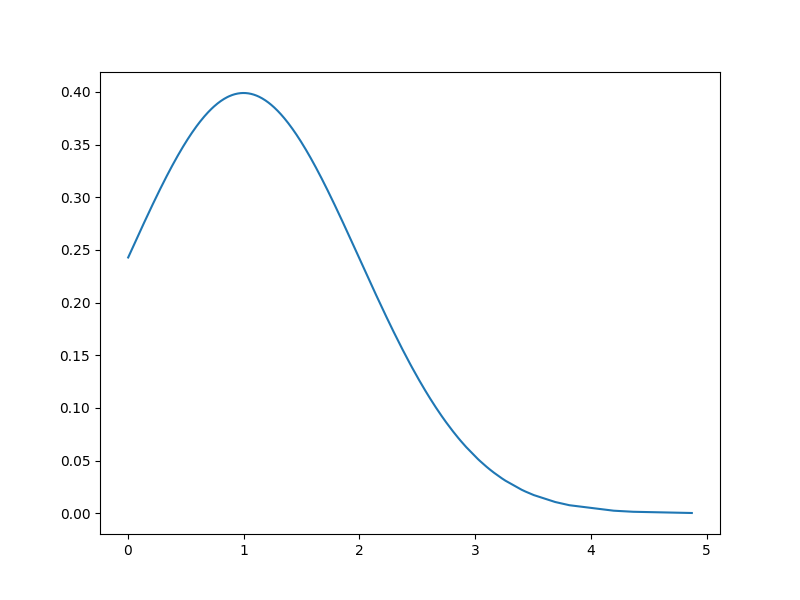

In [141]:
# === Synthetic truncated dataset ===
dist = MultivariateNormal(true_mu, true_var)
samples = dist.sample((1000,))
# Define truncation region: S = {z > 0}
def phi(z):
#     return ch.ones_like(z).bool()
    return (z[..., 0] > 0)
S = samples[phi(samples)]

x_obs = S.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

sorted_S = S.sort(dim=0)[0]
pdf = ch.exp(dist.log_prob(sorted_S))

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(sorted_S, pdf)

<IPython.core.display.Javascript object>


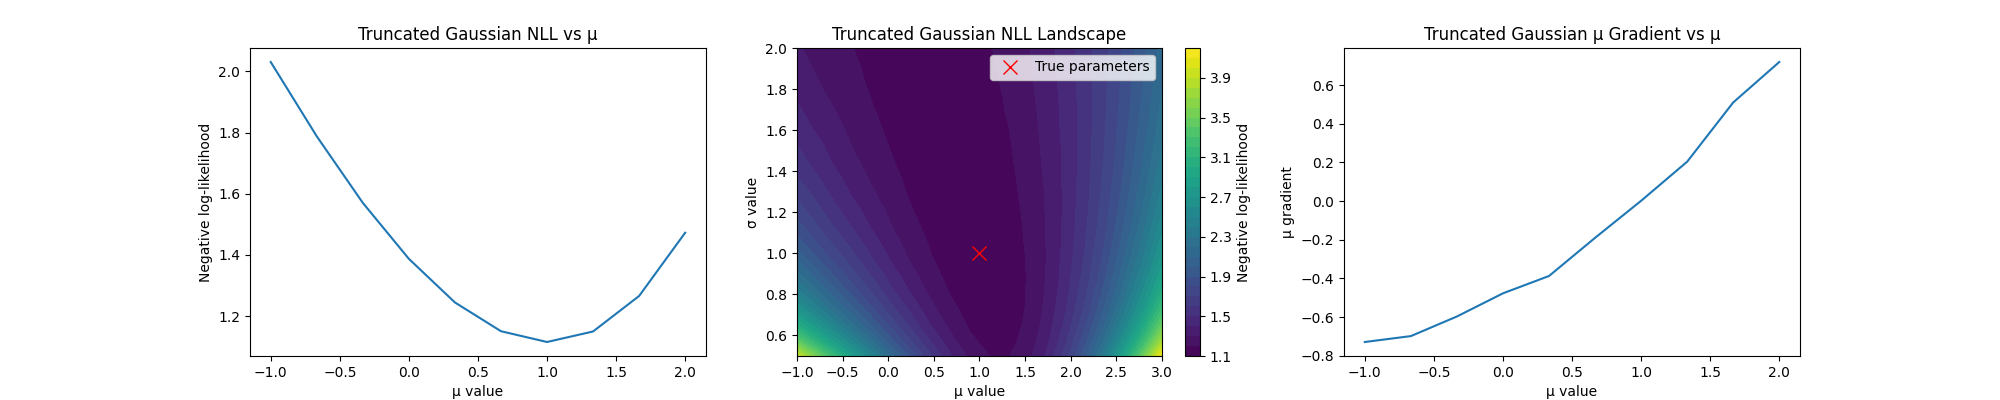

In [142]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
sampler = PreSampled(dims)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loss, grad = trunc_nll(phi, MU[i, j][...,None], var, data, known_cov=True, sampler=sampler)
        Z[i, j] = loss

# === Plot the loss landscape ===
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))

mus = ch.linspace(-1, 2, 10)
losses = [trunc_nll(phi, ch.tensor([m]), true_var, data, sampler=sampler)[0] for m in mus]

ax1.plot(mus, losses)
ax1.set_xlabel("μ value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Gaussian NLL vs μ")

cp = ax2.contourf(MU, SIGMA, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax2, label="Negative log-likelihood")

ax2.set_title("Truncated Gaussian NLL Landscape")
ax2.set_xlabel("μ value")
ax2.set_ylabel("σ value")

# mark the ground truth
ax2.plot(true_mu.item(), true_var.sqrt().item(), 'rx', markersize=10, label="True parameters")
ax2.legend()
    
mu_grads = [trunc_nll(phi, ch.tensor([m]), true_var, data, known_cov=True)[1][1] for m in mus]

ax3.plot(mus, mu_grads)
ax3.set_xlabel("μ value")
ax3.set_ylabel("μ gradient")
ax3.set_title("Truncated Gaussian μ Gradient vs μ")


plt.show()

<IPython.core.display.Javascript object>


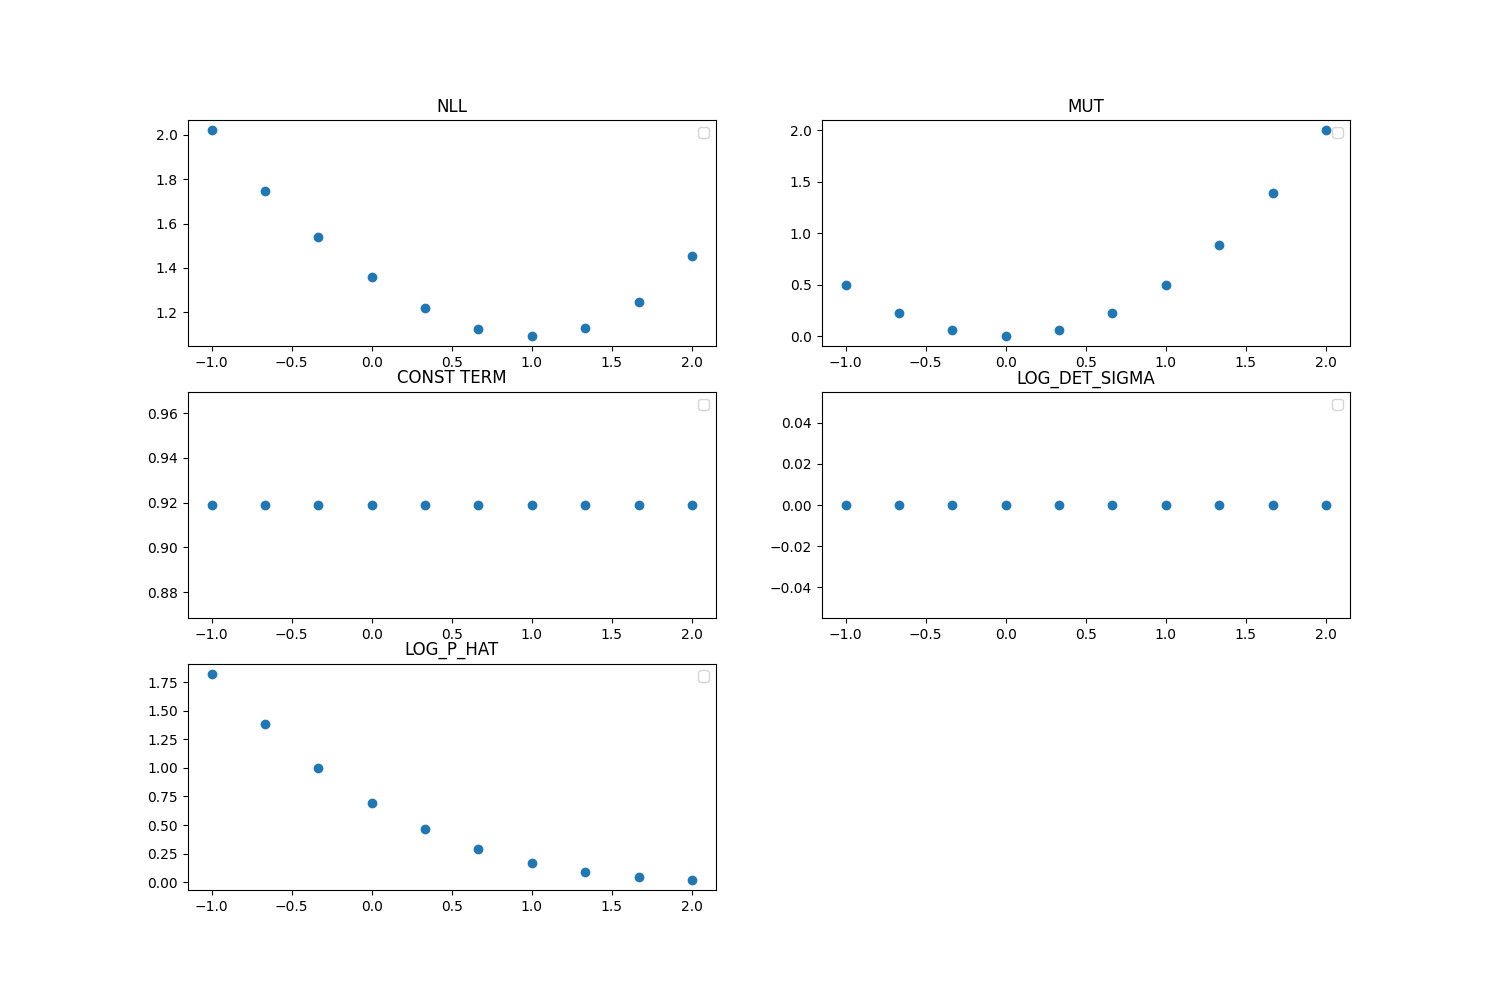

/tmp/ipykernel_81787/3343825002.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_81787/3343825002.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_81787/3343825002.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend()
/tmp/ipykernel_81787/3343825002.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend()
/tmp/ipykernel_81787/3343825002.py:87: UserWarning: No artists with labels found to put in legend.  Note

In [67]:
def trunc_loss_breakdown(mu, Sigma, data, known_cov=False):
    T = ch.inverse(Sigma)
    v = T @ mu
    S = data[:, :dims]

    sigma = T.inverse()
    L = ch.linalg.cholesky(sigma)

    # base Gaussian part
    quad = 0.5 * (S @ T * S).sum(dim=1)
    linear = (S @ v)
    base = quad - linear  # (batch,)

    # normalization stuff
    muT_T_mu = 0.5 * (mu @ v)
    const_term = 0.5 * dims * math.log(2 * math.pi)
    logdet_sigma = 2 * ch.log(ch.diagonal(L)).sum()

    # Monte-Carlo truncation probability
    _, p_hat = rejection_sampling(mu, sigma, phi, dims, 100000)
    log_p_hat = ch.log(p_hat + 1e-12)

    log_I = muT_T_mu + const_term + 0.5 * logdet_sigma + log_p_hat

    # final NLL — IMPORTANT PART
    nll = base + log_I
    return (
        nll.mean(),
        muT_T_mu,
        const_term,
        0.5 * logdet_sigma,
        -log_p_hat,  # you may keep this to plot but it's NOT in the loss directly
    )



# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

mus = ch.linspace(-1, 2, 10)
NLL = []
MUT = []
CONST_TERM = []
LOG_DET_SIGMA = []
LOG_P_HAT = []
for mu in mus:    
    nll, muT_T_mu_t, const_term, log_det_sigma, log_p_hat = trunc_loss_breakdown(ch.Tensor([mu]), true_var, data, known_cov=False)
    NLL.append(nll)
    MUT.append(muT_T_mu_t)
    CONST_TERM.append(const_term)
    LOG_DET_SIGMA.append(log_det_sigma)
    LOG_P_HAT.append(log_p_hat)
    

fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(321)
ax1.scatter(mus.tolist(), NLL)
ax1.set_title('NLL')
ax1.legend()

ax2 = fig.add_subplot(322)
ax2.scatter(mus.tolist(), MUT)
ax2.set_title('MUT')
ax2.legend()

ax3 = fig.add_subplot(323)
ax3.scatter(mus.tolist(), CONST_TERM)
ax3.set_title('CONST TERM')
ax3.legend()

ax4 = fig.add_subplot(324)
ax4.scatter(mus.tolist(), LOG_DET_SIGMA)
ax4.set_title('LOG_DET_SIGMA')
ax4.legend()

ax5 = fig.add_subplot(325)
ax5.scatter(mus.tolist(), LOG_P_HAT)
ax5.set_title('LOG_P_HAT')
ax5.legend()





plt.show()



Ground truth: μ=1.000, σ=1.000
Minimum found: μ=0.931, σ=1.172, loss=1.112

Loss at ground truth: 1.114
Loss at minimum: 1.112
Difference: 0.004


<IPython.core.display.Javascript object>


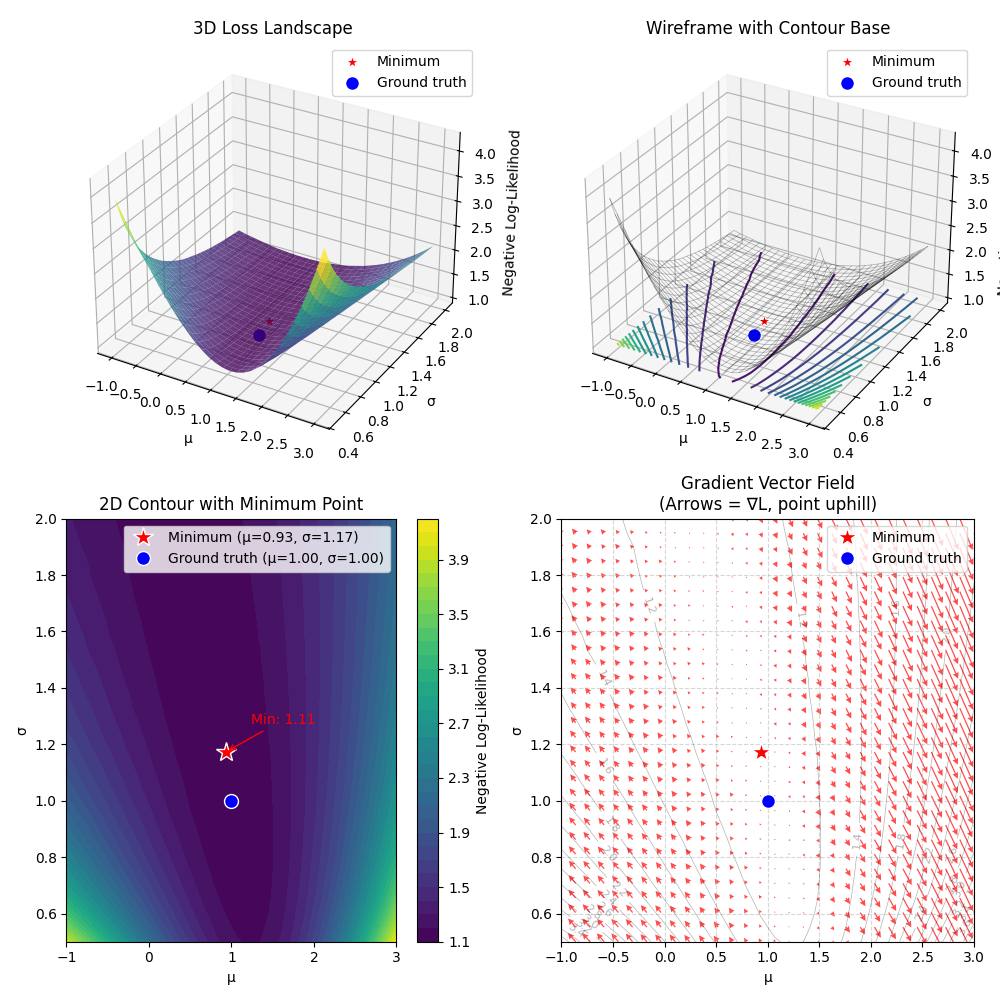

In [144]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 30)  # Increased resolution
sigma_values = ch.linspace(0.5, 2.0, 30)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=False)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
MU_GRAD = np.zeros_like(MU)
SIGMA_GRAD = ch.zeros_like(SIGMA) 
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loss, grad = trunc_nll(phi, MU[i, j][...,None], var, data)
        Z[i, j] = loss
        MU_GRAD[i, j] = grad[1]
        SIGMA_GRAD[i, j] = grad[0]

# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")
print(f"\nLoss at ground truth: {trunc_nll(phi, true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(phi, true_mu, true_var, data)[0] - min_loss:.3f}")

# === Create 3D visualization ===
fig = plt.figure(figsize=(10, 10))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(221, projection='3d')
surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_xlabel('μ')
ax1.set_ylabel('σ')
ax1.set_zlabel('Negative Log-Likelihood')
ax1.set_title('3D Loss Landscape')
ax1.legend()

# Plot 2: 3D wireframe plot
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_wireframe(MU, SIGMA, Z, color='black', alpha=0.3, linewidth=0.5)
contour = ax2.contour(MU, SIGMA, Z, levels=15, offset=np.min(Z) - 0.1, cmap='viridis')
ax2.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('Wireframe with Contour Base')
ax2.legend()

# Plot 3: Heatmap with minimum point
ax3 = fig.add_subplot(223)
contourf = ax3.contourf(MU, SIGMA, Z, levels=30, cmap='viridis')
plt.colorbar(contourf, ax=ax3, label='Negative Log-Likelihood')

# Mark minimum and ground truth
ax3.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', 
        label=f'Minimum (μ={min_mu:.2f}, σ={min_sigma:.2f})')
ax3.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, 
        markeredgecolor='white', label=f'Ground truth (μ={true_mu.item():.2f}, σ={true_var.sqrt().item():.2f})')

# Add text annotation for the minimum point
ax3.annotate(f'Min: {min_loss:.2f}', 
            xy=(min_mu, min_sigma), 
            xytext=(min_mu+0.3, min_sigma+0.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

ax3.set_xlabel('μ')
ax3.set_ylabel('σ')
ax3.set_title('2D Contour with Minimum Point')
ax3.legend()

# Plot 4: Gradient
ax4 = fig.add_subplot(224)

# Plot quiver
Q = ax4.quiver(MU, SIGMA, MU_GRAD, SIGMA_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax4.contour(MU, SIGMA, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax4.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax4.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax4.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax4.set_xlabel('μ')
ax4.set_ylabel('σ')
ax4.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Two Dimensional Gaussian

In [145]:
# === Ground truth parameters ===
dims = 2
true_mu = ch.ones(dims)
true_var = ch.eye(dims)
true_T = ch.inverse(true_var)
true_v = true_T @ true_mu

print(f'true mean: {true_mu.tolist()}')
print(f'true covariance: {true_var.tolist()}')

true mean: [1.0, 1.0]
true covariance: [[1.0, 0.0], [0.0, 1.0]]


acceptance rate: 0.7108
Observed mean (x): [[0.9881591796875, 1.0183241367340088]]


<IPython.core.display.Javascript object>


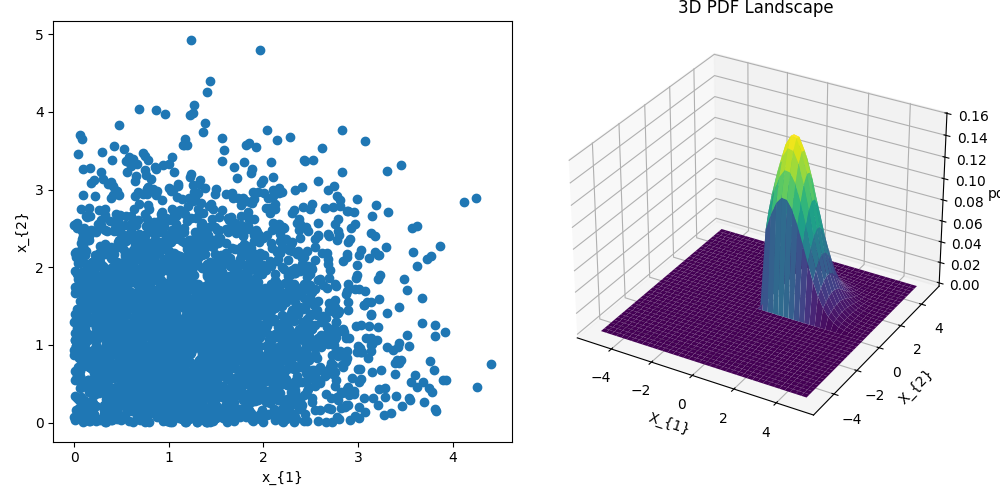

In [147]:
M = MultivariateNormal(ch.zeros(dims), ch.eye(dims))
SAMPLES = M.sample([1000])

# === Synthetic truncated dataset ===
dist = MultivariateNormal(true_mu, true_var)
samples = dist.sample((5000,))
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
# === Truncation region ===
def phi(z):
    # Keep only samples where both coordinates > 0
    return (z > 0).prod(dim=-1, keepdim=True)
mask = phi(samples)
S = samples[mask.nonzero()[:,0]]
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

acceptance_rate = S.size(0) / samples.size(0)
print(f'acceptance rate: {acceptance_rate}')

x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample
print(f"Observed mean (x): {x_obs.tolist()}")

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
ax1.scatter(S[:,0], S[:,1])
ax1.set_xlabel('x_{1}')
ax1.set_ylabel('x_{2}')

x_ = ch.linspace(-5.0, 5.0, 40)
y_ = ch.linspace(-5.0, 5.0, 40)
X, Y = ch.meshgrid(x_, y_)

coords = ch.stack([X, Y], dim=-1)
coords_flat = coords.reshape(-1, 2)

pdfs = ch.exp(dist.log_prob(coords_flat))[...,None]
mask = phi(coords_flat)

truncated_pdfs = (pdfs * mask).reshape(X.shape)   
        
ax2 = fig.add_subplot(122, projection='3d')

ax2.plot_surface(X, Y, truncated_pdfs,cmap='viridis',linewidth=0)
ax2.set_xlabel('X_{1}')
ax2.set_ylabel('X_{2}')
ax2.set_zlabel('pdf')
ax2.set_title('3D PDF Landscape')

plt.tight_layout()
plt.show()

acceptance rate: 0.004466562531888485
acceptance rate: 0.005537679418921471
acceptance rate: 0.006853082217276096
acceptance rate: 0.008281074464321136
acceptance rate: 0.009972178377211094
acceptance rate: 0.005577166564762592
acceptance rate: 0.006906758528202772
acceptance rate: 0.008492966182529926
acceptance rate: 0.006828503217548132
acceptance rate: 0.00847571436315775
acceptance rate: 0.00831099133938551
acceptance rate: 0.00995287112891674


<IPython.core.display.Javascript object>


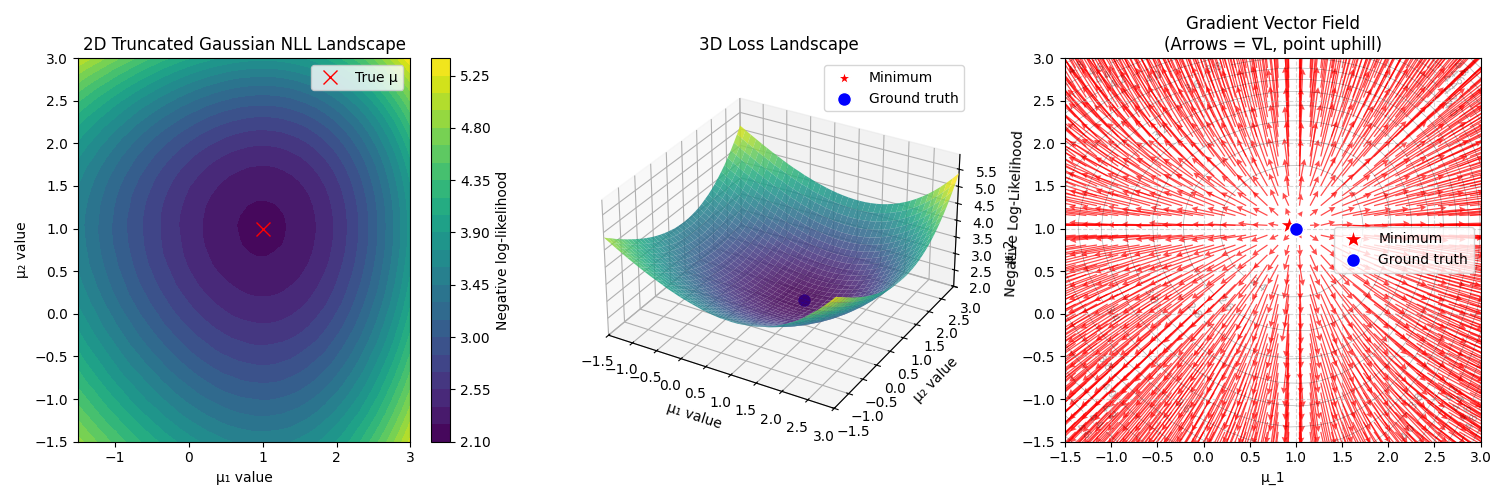


Loss at ground truth: 2.214
Loss at minimum: 2.214
Difference: 0.002


In [150]:
# === Parameter grid for μ₁ and μ₂ ===
mu1_vals = ch.linspace(-1.5, 3.0, 40)
mu2_vals = ch.linspace(-1.5, 3.0, 40)
MU1, MU2 = ch.meshgrid(mu1_vals, mu2_vals)

Z = np.zeros_like(MU1)
MU1_GRAD = ch.zeros_like(MU1)
MU2_GRAD = ch.zeros_like(MU2)
for i in range(len(mu2_vals)):
    for j in range(len(mu1_vals)):
        mu_vec = ch.tensor([MU1[i, j], MU2[i, j]])
        loss, grad = trunc_nll(phi, mu_vec, true_var, data, known_cov=True)
        Z[i, j] = loss
        MU1_GRAD[i, j] = grad[dims**2]
        MU2_GRAD[i, j] = grad[dims**2 + 1]
        
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu_1, min_mu_2 = MU1[min_idx], MU2[min_idx]
min_loss = Z[min_idx]

fig = plt.figure(figsize=(15, 5))

# === 2D contour plot ===
ax1 = fig.add_subplot(131)
cp = ax1.contourf(MU1, MU2, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")

ax1.set_title("2D Truncated Gaussian NLL Landscape")
ax1.set_xlabel("μ₁ value")
ax1.set_ylabel("μ₂ value")

# mark the ground truth
ax1.plot(true_mu[0].item(), true_mu[1].item(), 'rx', markersize=10, label="True μ")
ax1.legend()

# === 3D surface plot ===
ax2 = fig.add_subplot(132, projection='3d')
surf = ax2.plot_surface(MU1, MU2, Z, cmap='viridis', alpha=0.85,
                        linewidth=0, antialiased=True)

# plot key points
ax2.scatter([min_mu_1], [min_mu_2], [min_loss],
            color='red', s=100, label='Minimum', marker='*', edgecolors='white')
ax2.scatter([true_mu[0].item()], [true_mu[1].item()], [np.min(Z)],
            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')

# formatting
ax2.set_xlabel('μ₁ value')
ax2.set_ylabel('μ₂ value')
ax2.set_zlabel('Negative Log-Likelihood')
ax2.set_title('3D Loss Landscape')
ax2.legend()

# fix clipping
ax2.set_box_aspect((1, 1, 0.6))  # prevents z from being squashed
ax2.set_xlim(MU1.min(), MU1.max())
ax2.set_ylim(MU2.min(), MU2.max())
ax2.set_zlim(Z.min() - 0.1 * abs(Z.min()), Z.max() + 0.1 * abs(Z.max()))

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, MU2, MU1_GRAD, MU2_GRAD,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, MU2, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(min_mu_1, min_mu_2, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax3.plot(true_mu[0].item(), true_mu[1].item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('μ_2')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
print(f"\nLoss at ground truth: {trunc_nll(phi, true_mu, true_var, data, known_cov=True)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(phi, true_mu, true_var, data, known_cov=True)[0] - min_loss:.3f}")

/tmp/ipykernel_7727/3369298514.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)


<IPython.core.display.Javascript object>


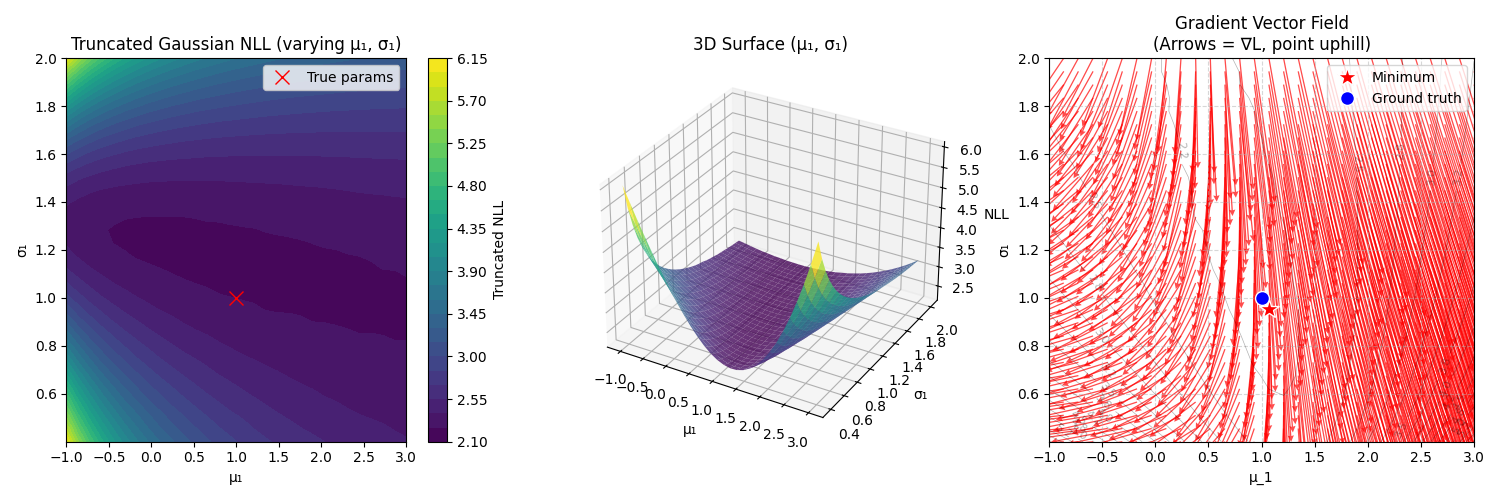


Loss at ground truth: 2.213
Loss at minimum: 2.213
Difference: 0.002


In [151]:
# ==== Vary μ₁ and σ₁ (fix μ₂, σ₂) ====
mu1_vals = ch.linspace(-1, 3, 30)
sigma1_vals = ch.linspace(0.4, 2.0, 30)
MU1, SIGMA1 = ch.meshgrid(mu1_vals, sigma1_vals)
Z_mu_sigma = ch.zeros_like(MU1)
GRAD_MU1 = ch.zeros_like(MU1)
GRAD_SIGMA1 = ch.zeros_like(SIGMA1)

sigma2_fixed = 1.0

for i in range(len(sigma1_vals)):
    for j in range(len(mu1_vals)):
        mu = ch.tensor([MU1[i, j], true_mu[1]])
        Sigma = ch.diag(ch.tensor([SIGMA1[i, j], sigma2_fixed]))
        loss, grad = trunc_nll(phi, mu, Sigma, data)
        Z_mu_sigma[i, j] = loss
        GRAD_MU1[i, j] = grad[4]
        GRAD_SIGMA1[i, j] = grad[0]  
        
min_idx = np.unravel_index(np.argmin(Z_mu_sigma), Z_mu_sigma.shape)
min_mu_1, min_sigma_1 = MU1[min_idx], SIGMA1[min_idx]
min_loss = Z_mu_sigma[min_idx]

# ==== Visualization ====
fig = plt.figure(figsize=(15, 5))

ax1 = fig.add_subplot(1, 3, 1)
cp = ax1.contourf(mu1_vals, sigma1_vals, Z_mu_sigma, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Truncated NLL")
ax1.plot(true_mu[0], 1.0, "rx", markersize=10, label="True params")
ax1.set_title("Truncated Gaussian NLL (varying μ₁, σ₁)")
ax1.set_xlabel("μ₁")
ax1.set_ylabel("σ₁")
ax1.legend()

ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax2.plot_surface(MU1, SIGMA1, Z_mu_sigma, cmap="viridis", alpha=0.8, linewidth=0)
ax2.set_xlabel("μ₁")
ax2.set_ylabel("σ₁")
ax2.set_zlabel("NLL")
ax2.set_title("3D Surface (μ₁, σ₁)")

# Plot 3: Gradient
ax3 = fig.add_subplot(133)

# Plot quiver
Q = ax3.quiver(MU1, SIGMA1, GRAD_MU1, GRAD_SIGMA1,
               color='red', alpha=0.7, width=0.003, scale=5, headwidth=5)

# Add contour of loss for context
contour = ax3.contour(MU1, SIGMA1, Z_mu_sigma, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax3.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax3.plot(min_mu_1, min_sigma_1, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax3.plot(true_mu[0].item(), 1.0, 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax3.set_xlabel('μ_1')
ax3.set_ylabel('σ₁')
ax3.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# === Additional analysis ===
print(f"\nLoss at ground truth: {trunc_nll(phi, true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(phi, true_mu, true_var, data)[0] - min_loss:.3f}")

# 10 Dimensional Gaussians

In [17]:
dims = 10
true_mu = ch.randn(dims) 
true_Sigma = 10.0 * ch.eye(dims)
dist = MultivariateNormal(true_mu, true_Sigma)

print(f'true mu: {true_mu.tolist()}')
print(f'true Sigma: {true_Sigma.tolist()}')

true mu: [-0.683891773223877, 0.655558168888092, -0.9559581875801086, 1.8891713619232178, -0.7871607542037964, 0.10608850419521332, 0.8894955515861511, -0.9623016715049744, 0.9789290428161621, -0.3489947021007538]
true Sigma: [[10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0]]


# Random Matrix Projection

Observed mean (x): [[-0.6568290591239929, 0.6252155900001526, -1.027417540550232, 1.9176138639450073, -0.7649640440940857, 0.08759535849094391, 0.8327792286872864, -0.9698857665061951, 0.980516791343689, -0.3497180938720703]]
Total samples: 10000
Truncated samples: 9979
Acceptance rate: 0.9979
Min 10D norm in truncated set: 4.509
Max 10D norm: 19.237
Effective 2D radius (min): 0.12


<IPython.core.display.Javascript object>


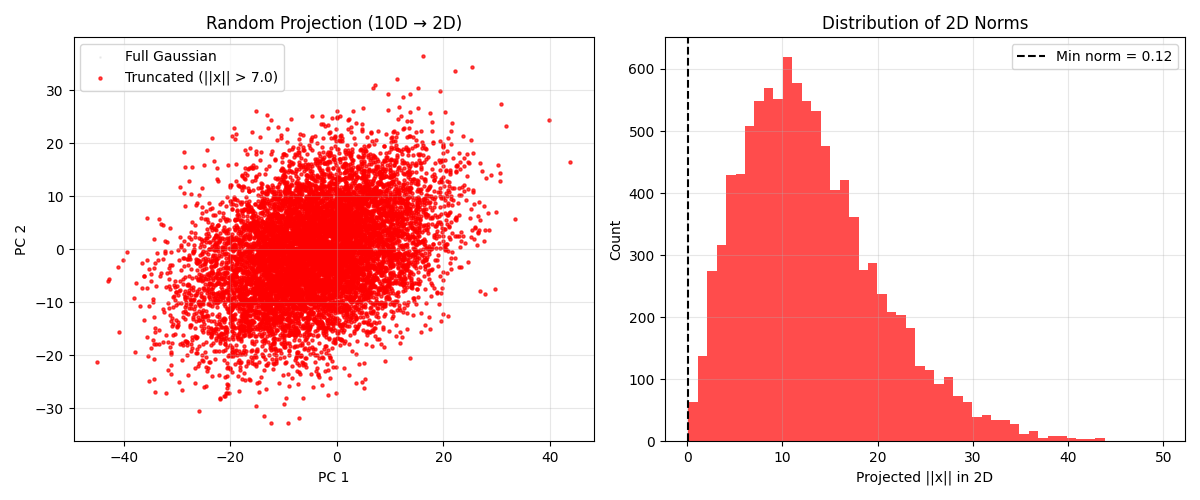

In [18]:
dist = MultivariateNormal(true_mu, true_Sigma)
samples = dist.sample([10000])
# === Truncation region ===
def phi(z):
    # Keep only samples, where norm of the sample is larger than 4.5
    return samples.norm(dim=1, keepdim=True) > 4.5
mask = phi(samples)
S = samples[mask.nonzero()[:,0]]
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)
acceptance_rate = S.size(0) / samples.size(0)
x_obs = samples.mean(0, keepdim=True) # empirical mean as observed sample

print(f"Observed mean (x): {x_obs.tolist()}")
print(f"Total samples: {samples.shape[0]}")
print(f"Truncated samples: {S.shape[0]}")
print(f"Acceptance rate: {S.shape[0] / samples.shape[0]:.4f}")
print(f"Min 10D norm in truncated set: {S.norm(dim=1).min().item():.3f}")
print(f"Max 10D norm: {S.norm(dim=1).max().item():.3f}")

# Project with a random matrix
W = ch.randn(10, 2)
S_2d = S @ W
samples_full_2d = samples @ W

projected_norms = np.linalg.norm(S_2d, axis=1)
R_eff = projected_norms.min()  # or use percentile
print(f"Effective 2D radius (min): {R_eff:.2f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Full vs truncated in 2D PCA space
ax1.scatter(samples_full_2d[:, 0], samples_full_2d[:, 1], 
           s=1, alpha=0.3, label='Full Gaussian', color='lightgray')
ax1.scatter(S_2d[:, 0], S_2d[:, 1], 
           s=5, alpha=0.7, label='Truncated (||x|| > 7.0)', color='red')
ax1.set_title('Random Projection (10D → 2D)')
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of projected norms
ax2.hist(projected_norms, bins=50, color='red', alpha=0.7)
ax2.axvline(R_eff, color='black', linestyle='--', label=f'Min norm = {R_eff:.2f}')
ax2.set_xlabel('Projected ||x|| in 2D')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of 2D Norms')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Marginzalized Projection 

<IPython.core.display.Javascript object>


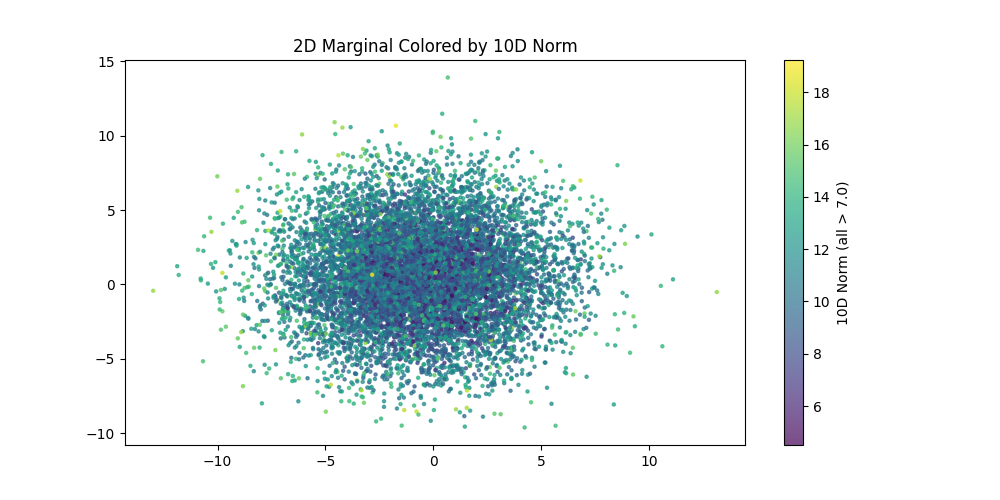

In [19]:
x_marg = S[:, :2].cpu()
norms_10d = S.norm(dim=1).cpu()

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
fig1 = ax1.scatter(x_marg[:, 0], x_marg[:, 1], c=norms_10d, s=5, alpha=0.7)
plt.colorbar(fig1, ax=ax1, label='10D Norm (all > 7.0)')
ax1.set_title('2D Marginal Colored by 10D Norm')
plt.show()

In [211]:
from delphi import oracle

dims = 1

true_mu, true_var = ch.zeros(dims), ch.eye(dims)
M = MultivariateNormal(true_mu, true_var) 
print(f'ground truth loc: {true_mu}')
print(f'ground truth var: {true_var}')
samples = M.rsample([1000,])
print(f'num total samples: {samples.size(0)}')
# generate ground-truth data
phi = oracle.Left_Distribution(ch.Tensor([0.0]))
# truncate
indices = phi(samples).nonzero()[:,0]
S = samples[indices]
print(f'num truncated samples: {S.size(0)}')
alpha = S.size(0) / samples.size(0)
emp_loc = S.mean(0)
emp_var = S.var(0)
print(f"emp loc: {emp_loc}")
print(f'emp var: {emp_var}')

ground truth loc: tensor([0.])
ground truth var: tensor([[1.]])
num total samples: 1000
num truncated samples: 487
emp loc: tensor([0.7706])
emp var: tensor([0.3458])


In [212]:
from delphi.distributions import TruncatedNormal
from delphi.utils.helpers import Parameters

S_std_norm = (S - emp_loc) 
phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten())

# train algorithm
args = Parameters({
                    'epochs': 20, 
                    'batch_size': 100, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
                    'num_samples': 10000,
                }) 
truncated = TruncatedNormal(args,
                              phi_std_norm, 
                              alpha, 
                              dims,
                              variance=ch.eye(1))
truncated.fit(S_std_norm)

rescale_loc = truncated.best_loc_ + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_variance_
print(f"pred var: {rescale_var}")

args: {'amsgrad': False,
 'batch_size': 100,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'epochs': 20,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'sgd',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'stats': True,
 'step_lr': 100,
 'step_lr_gamma': 0.9,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': Fal

In [213]:
dims = 1
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=True)
sampler = PreSampled(dims)
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

mus = ch.linspace(-1, 2, 10)
losses = [trunc_nll(phi, ch.tensor([m]), ch.eye(1), data, sampler=sampler)[0] for m in mus]

<IPython.core.display.Javascript object>


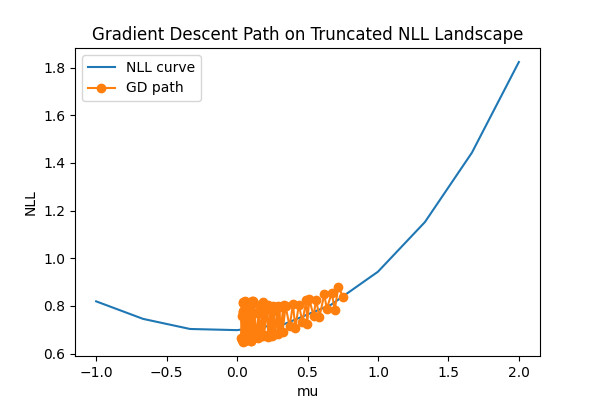

In [214]:
mu_history = truncated.trainer.param_history[:,1].detach() + emp_loc
loss_history = truncated.trainer.loss_history.detach()

plt.figure(figsize=(6,4))
plt.plot(mus, losses, label="NLL curve")
plt.plot(mu_history, loss_history, marker="o", label="GD path")
plt.xlabel("mu")
plt.ylabel("NLL")
plt.title("Gradient Descent Path on Truncated NLL Landscape")
plt.legend()
plt.show()

In [215]:
S_std_norm = (S - emp_loc) / (emp_var ** .5)
phi_std_norm = oracle.Left_Distribution((phi.left - emp_loc).flatten() / (emp_var ** .5))


# train algorithm
args = Parameters({
                    'epochs': 20, 
                    'batch_size': 50, 
                    'trials': 1, 
                    'verbose': True,
                    'lr': 1e-1,
                    'step_lr_gamma': 1.0,
                    'num_samples': 10000,
                    'optimizer': 'adam'
                }) 
truncated = TruncatedNormal(args,
                              phi_std_norm, 
                              alpha, 
                              dims)
truncated.fit(S_std_norm)

rescale_loc = truncated.best_loc_ * (emp_var ** .5) + emp_loc
print(f"pred loc: {rescale_loc}")
rescale_var = truncated.best_variance_ * emp_var
print(f"pred var: {rescale_var}")

args: {'amsgrad': False,
 'batch_size': 50,
 'beta1': 0.9,
 'beta2': 0.999,
 'capturable': False,
 'constant': False,
 'dampening': 0.0,
 'damping': 0.001,
 'device': 'cpu',
 'differentiable': False,
 'distribution': True,
 'epochs': 20,
 'eps': 1e-05,
 'gamma': 0.1,
 'hessian_approx': 'auto',
 'lr': 0.1,
 'max_update_norm': 1.0,
 'maximize': False,
 'milestones': [30, 60, 90],
 'min_lr': 0.0,
 'momentum': 0.0,
 'nesterov': False,
 'num_samples': 10000,
 'optimizer': 'adam',
 'plateau_cooldown': 0,
 'plateau_eps': 1e-08,
 'plateau_factor': 0.1,
 'plateau_mode': 'min',
 'plateau_patience': 10,
 'plateau_threshold': 0.0001,
 'plateau_threshold_mode': 'rel',
 'r': 1.0,
 'rate': 1.5,
 'stats': True,
 'step_lr': 100,
 'step_lr_gamma': 1.0,
 'tol': 0.1,
 'trials': 1,
 'val': 0.2,
 'verbose': True,
 'weight_decay': 0.0,
 'workers': 0}
trial: 1
Creating Adam optimizer: {'lr': 0.1, 'betas': (0.9, 0.999), 'eps': 1e-05, 'weight_decay': 0.0, 'amsgrad': False, 'maximize': False, 'capturable': False

In [216]:
truncated.final_loc_, truncated.final_covariance_matrix_

(tensor([-0.4189]), tensor([[5.1995]]))

In [217]:
truncated.final_loc_ * (emp_var ** .5) + emp_loc, truncated.best_variance_ * emp_var

(tensor([0.5243]), tensor([[0.8679]]))

Ground truth: μ=0.000, σ=1.000
Minimum found: μ=-0.368, σ=1.211, loss=0.694

Loss at ground truth: 0.697
Loss at minimum: 0.694
Difference: 0.002


<IPython.core.display.Javascript object>


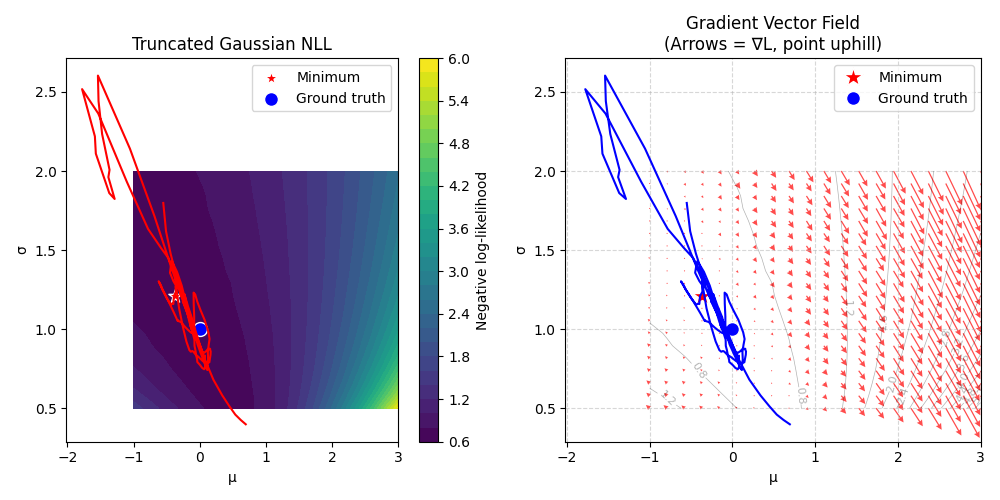

In [218]:
# === Parameter grids ===
mu_values = ch.linspace(-1.0, 3.0, 20)
sigma_values = ch.linspace(0.5, 2.0, 20)
MU, SIGMA = ch.meshgrid(mu_values, sigma_values)

# DATA 
trunc_multi_norm_score = TruncatedMultivariateNormalScore(known_cov=False)
sampler = PreSampled(dims, )
S_grad = trunc_multi_norm_score(S)
data = ch.cat([S, S_grad], dim=1)

# === Compute NLL over the grid ===
Z = np.zeros_like(MU)
MU_GRAD = np.zeros_like(MU)
SIGMA_GRAD = ch.zeros_like(SIGMA) 
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        var = ch.Tensor([[SIGMA[i, j]]])
        loc = MU[i, j][...,None]
        loss, grad = trunc_nll(phi, loc, var, data, known_cov=False, sampler=sampler)
        Z[i, j] = loss
        MU_GRAD[i, j] = grad[1]
        SIGMA_GRAD[i, j] = grad[0]
        
# Find the minimum point
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
min_mu = MU[min_idx]
min_sigma = SIGMA[min_idx]
min_loss = Z[min_idx]

# === Analysis ===
print(f"Ground truth: μ={true_mu.item():.3f}, σ={true_var.sqrt().item():.3f}")
print(f"Minimum found: μ={min_mu:.3f}, σ={min_sigma:.3f}, loss={min_loss:.3f}")
print(f"\nLoss at ground truth: {trunc_nll(phi, true_mu, true_var, data)[0]:.3f}")
print(f"Loss at minimum: {min_loss:.3f}")
print(f"Difference: {trunc_nll(phi, true_mu, true_var, data)[0] - min_loss:.3f}")        
        
fig = plt.figure(figsize=(10, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(121)
cp = ax1.contourf(MU, SIGMA, Z, levels=30, cmap="viridis")
plt.colorbar(cp, ax=ax1, label="Negative log-likelihood")
# surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
#                        linewidth=0, antialiased=True)
ax1.scatter([min_mu], [min_sigma], color='red', s=100, 
           label='Minimum', marker='*', edgecolors='white')
ax1.scatter([true_mu.item()], [true_var.sqrt().item()], 
           color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
ax1.set_title("Truncated Gaussian NLL")
ax1.set_xlabel("μ")
ax1.set_ylabel("σ")
ax1.legend()
ax1.legend()

param_history = truncated.trainer.param_history 

T = param_history[:,0]
v = param_history[:,1]

SIGMA_ = (1/T[...,None])
MU_ = SIGMA_ * v[...,None]

SIGMA_ = SIGMA_ * emp_var
MU_ = MU_ * (emp_var ** .5) + emp_loc

ax1.plot(MU_, SIGMA_, color='red')

ax2 = fig.add_subplot(122)

# Plot quiver
Q = ax2.quiver(MU, SIGMA, MU_GRAD, SIGMA_GRAD,
               color='red', alpha=0.7, width=0.003, scale=50, headwidth=5)

# Add contour of loss for context
contour = ax2.contour(MU, SIGMA, Z, levels=15, colors='black', alpha=0.3, linewidths=0.5)
ax2.clabel(contour, inline=True, fontsize=8, fmt="%.1f")

# Mark minimum and ground truth
ax2.plot(min_mu, min_sigma, 'r*', markersize=15, markeredgecolor='white', label='Minimum')
ax2.plot(true_mu.item(), true_var.sqrt().item(), 'bo', markersize=10, markeredgecolor='white', label='Ground truth')

ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_title('Gradient Vector Field\n(Arrows = ∇L, point uphill)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

ax2.plot(MU_, SIGMA_, color='blue')


plt.tight_layout()
plt.show()

In [186]:
len(truncated.train_loader_.dataset), S.size(0) * .8

(385, 384.8)

In [86]:
param_history = truncated.trainer.param_history 


T = param_history[:,0]
v = param_history[:,1]
SIGMA = (1/T[...,None])
MU = SIGMA * v[...,None]

SIGMA = SIGMA * emp_var
MU = MU * (emp_var ** .5) + emp_loc

In [161]:
loss_history = truncated.trainer.loss_history
ch.argmin(loss_history)

tensor(171)

In [202]:
truncated.optimizer

SGD (
Parameter Group 0
    dampening: 0.0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.1
    maximize: False
    momentum: 0.0
    nesterov: False
    weight_decay: 0.0
)

In [201]:
argmin = ch.argmin(ch.abs(0 - MU_))
MU_[argmin], SIGMA_[argmin]

(tensor([-0.0043]), tensor([0.9805]))

In [163]:
best_params = param_history[461]

best_var, best_mu = best_params[0], best_params[1]

best_sigma = 1/best_var

best_loc = best_sigma*best_mu

best_sigma * emp_var, best_loc * (emp_var ** .5) + emp_loc

(tensor([0.8831]), tensor([0.1193]))

<IPython.core.display.Javascript object>


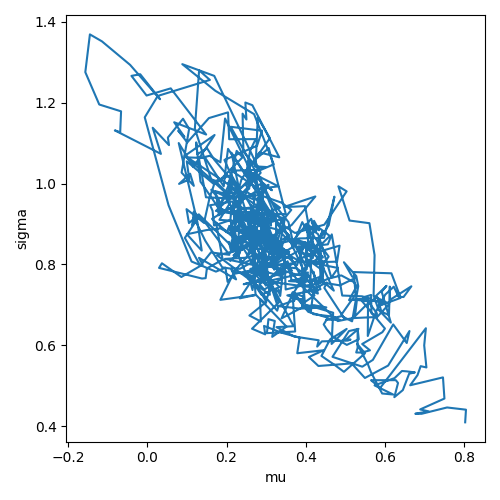

In [88]:
param_history, loss_history = truncated.trainer.param_history, truncated.trainer.loss_history


fig = plt.figure(figsize=(5, 5))

# Plot 1: 3D surface plot
ax1 = fig.add_subplot(111)
# surf = ax1.plot_surface(MU, SIGMA, Z, cmap='viridis', alpha=0.8, 
#                        linewidth=0, antialiased=True)
# ax1.scatter([min_mu], [min_sigma], [min_loss], color='red', s=100, 
#            label='Minimum', marker='*', edgecolors='white')
# ax1.scatter([true_mu.item()], [true_var.sqrt().item()], [np.min(Z)], 
#            color='blue', s=100, label='Ground truth', marker='o', edgecolors='white')
# ax1.set_xlabel('μ')
# ax1.set_ylabel('σ')
# ax1.set_zlabel('Negative Log-Likelihood')
# ax1.set_title('3D Loss Landscape')
# ax1.legend()

ax1.plot(MU, SIGMA)
ax1.set_xlabel('mu')
ax1.set_ylabel('sigma')


plt.tight_layout()
plt.show()

In [90]:
MU

tensor([0.3301])

In [85]:
emp_loc

tensor([0.8317])

In [ ]:
# Vary mu[0] and sigma[0], fix others
mu0_vals = ch.linspace(true_mu[0] - 2, true_mu[0] + 2, 30)
sigma0_vals = ch.linspace(0.5, 2.0, 30)
MU0, SIGMA0 = ch.meshgrid(mu0_vals, sigma0_vals)

Z = np.zeros((len(sigma0_vals), len(mu0_vals)))
GRAD_MU0 = np.zeros_like(Z)
GRAD_SIGMA0 = np.zeros_like(Z)

for i in range(len(sigma0_vals)):
    for j in range(len(mu0_vals)):
        # Build full mu and Sigma
        mu = true_mu.clone()
        mu[0] = MU0[i, j]
        
        sigma = true_sigma.clone()
        sigma[0] = SIGMA0[i, j]
        Sigma = ch.diag(sigma ** 2)
        
        loss, grad = trunc_nll(mu, Sigma, data, known_cov=False)
        Z[i, j] = loss
        
        # Extract ∂L/∂μ₀ and ∂L/∂σ₀
        dL_dv0 = grad[dims*dims + 0]           # ∂L/∂v₀
        dL_dT00 = grad[0]                      # ∂L/∂T₀₀ (since T is diagonal, T₀₀ is first)
        
        T00 = 1.0 / (sigma[0] ** 2)
        dL_dmu0 = dL_dv0 * T00
        dL_dsigma0 = dL_dT00 * (-2.0 / (sigma[0] ** 3))
        
        GRAD_MU0[i, j] = dL_dmu0
        GRAD_SIGMA0[i, j] = dL_dsigma0